<a href="https://colab.research.google.com/github/mercet3434/a/blob/main/notebooks/pneumonia_detection_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import random

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_280060e5ba0bd82c7de5062d611804c6"

In [ ]:
!kaggle datasets list -s pneumonia

ref                                                            title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
paultimothymooney/chest-xray-pneumonia                         Chest X-Ray Images (Pneumonia)                       2463365435  2018-03-24 19:41:59.603000         619203       7515  0.75             
pcbreviglieri/pneumonia-xray-images                            Pneumonia X-Ray Images                               1225740412  2020-05-18 14:32:09.660000          12515        101  0.9375           
iamtapendu/rsna-pneumonia-processed-dataset                    RSNA Pneumonia Processed Dataset                    11748997093  2024-11-10 17:28:20.063000           4293         31  1                


In [ ]:
!mkdir -p /content/dataset

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content/dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:11<00:00, 214MB/s]



In [ ]:
!ls /content/dataset

chest_xray


In [ ]:
!ls /content/dataset/chest_xray

chest_xray  __MACOSX  test  train  val


In [ ]:
base_dir = "/content/dataset/chest_xray"

train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")
val_dir = os.path.join(base_dir, "val")

print("Train path:", train_dir)
print("Test path:", test_dir)
print("Validation path:", val_dir)

print("Train classes:", os.listdir(train_dir))
print("Test classes:", os.listdir(test_dir))
print("Validation classes:", os.listdir(val_dir))

Train path: /content/dataset/chest_xray/train
Test path: /content/dataset/chest_xray/test
Validation path: /content/dataset/chest_xray/val
Train classes: ['PNEUMONIA', 'NORMAL']
Test classes: ['PNEUMONIA', 'NORMAL']
Validation classes: ['PNEUMONIA', 'NORMAL']


In [ ]:
for folder_name, folder_path in [("Train", train_dir), ("Test", test_dir), ("Validation", val_dir)]:
    print(f"\n{folder_name} Set:")
    for class_name in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_name)
        if os.path.isdir(class_path):
            print(class_name, ":", len(os.listdir(class_path)))


Train Set:
PNEUMONIA : 3875
NORMAL : 1341

Test Set:
PNEUMONIA : 390
NORMAL : 234

Validation Set:
PNEUMONIA : 8
NORMAL : 8


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


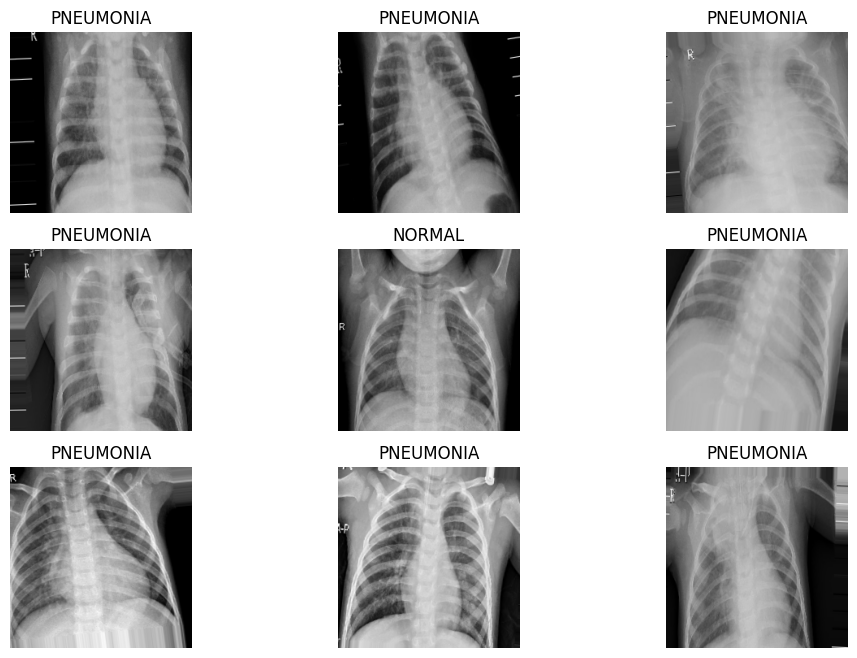

In [ ]:
class_names = ["NORMAL", "PNEUMONIA"]

images, labels = next(train_generator)

plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[int(labels[i])])
    plt.axis("off")

plt.show()

In [ ]:
custom_cnn = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

custom_cnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

custom_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,600,385 (9.92 MB)

 Trainable params: 2,600,385 (9.92 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

custom_history = custom_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 105s 806ms/step - accuracy: 0.8807 - loss: 0.2878 - val_accuracy: 0.8523 - val_loss: 0.2968 - learning_rate: 0.0010
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 103s 785ms/step - accuracy: 0.9039 - loss: 0.2365 - val_accuracy: 0.8965 - val_loss: 0.2170 - learning_rate: 0.0010
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 103s 784ms/step - accuracy: 0.9233 - loss: 0.2024 - val_accuracy: 0.9060 - val_loss: 0.2143 - learning_rate: 0.0010
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 103s 783ms/step - accuracy: 0.9240 - loss: 0.2035 - val_accuracy: 0.9291 - val_loss: 0.1876 - learning_rate: 0.0010
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 103s 790ms/step - accuracy: 0.9300 - loss: 0.1828 - val_accuracy: 0.9367 - val_loss: 0.1522 - learning_rate: 0.0010
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 104s 791ms/step - accuracy: 0.9343 - loss: 0.1854 - val_accuracy: 0.9367 - val_loss: 0.1518 - learning_rate: 0.0010
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 101s 775ms/step - accura

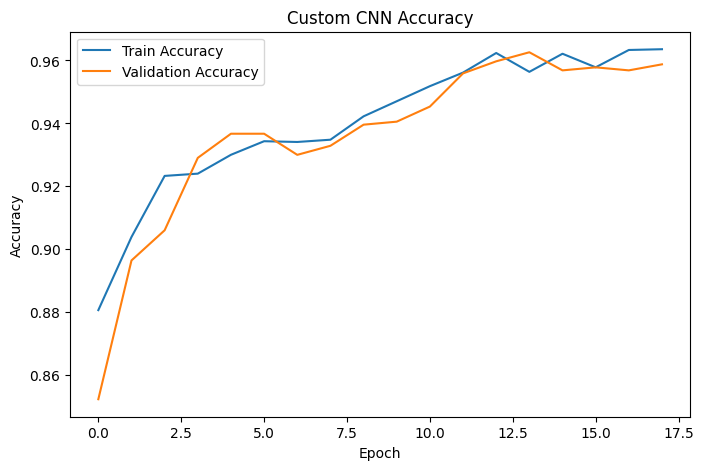

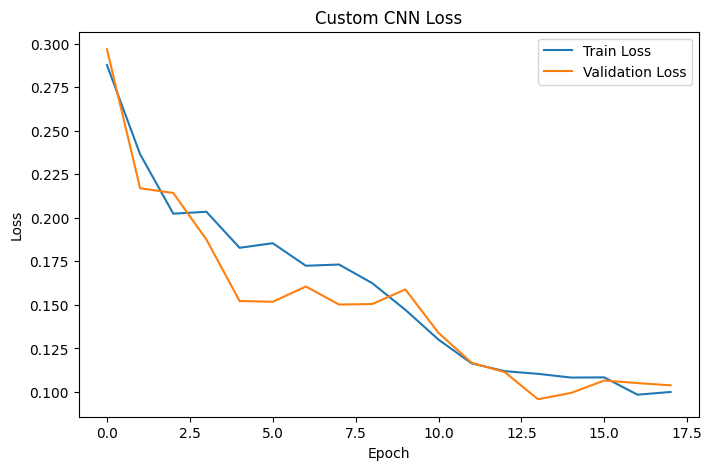

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(custom_history.history["accuracy"], label="Train Accuracy")
plt.plot(custom_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Custom CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(custom_history.history["loss"], label="Train Loss")
plt.plot(custom_history.history["val_loss"], label="Validation Loss")
plt.title("Custom CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
test_loss, test_acc = custom_cnn.evaluate(test_generator)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 265ms/step - accuracy: 0.8189 - loss: 0.6074
Test Accuracy: 0.8189102411270142
Test Loss: 0.6074334979057312


20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 416ms/step


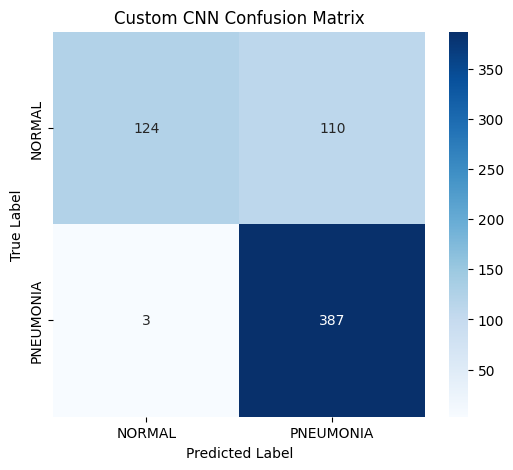

              precision    recall  f1-score   support

      NORMAL       0.98      0.53      0.69       234
   PNEUMONIA       0.78      0.99      0.87       390

    accuracy                           0.82       624
   macro avg       0.88      0.76      0.78       624
weighted avg       0.85      0.82      0.80       624



In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Test generator'ı başa sar
test_generator.reset()

# Tahmin al
predictions = custom_cnn.predict(test_generator)

# 0.5 üstü PNEUMONIA, altı NORMAL
y_pred = (predictions > 0.5).astype("int32").ravel()

# Gerçek etiketler
y_true = test_generator.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Custom CNN Confusion Matrix")
plt.show()

# Classification report
print(classification_report(
    y_true,
    y_pred,
    target_names=["NORMAL", "PNEUMONIA"]
))

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# İlk aşamada hazır modelin katmanlarını donduruyoruz
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(1, activation="sigmoid")(x)

mobilenet_model = Model(inputs=base_model.input, outputs=output)

mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop_mobilenet = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

reduce_lr_mobilenet = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=0.00001
)

history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop_mobilenet, reduce_lr_mobilenet]
)

Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 106s 809ms/step - accuracy: 0.9597 - loss: 0.1016 - val_accuracy: 0.9626 - val_loss: 0.1014 - learning_rate: 1.0000e-05
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 100s 763ms/step - accuracy: 0.9614 - loss: 0.0999 - val_accuracy: 0.9530 - val_loss: 0.1084 - learning_rate: 1.0000e-05
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 100s 764ms/step - accuracy: 0.9573 - loss: 0.1013 - val_accuracy: 0.9607 - val_loss: 0.1082 - learning_rate: 1.0000e-05
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 100s 765ms/step - accuracy: 0.9593 - loss: 0.1050 - val_accuracy: 0.9626 - val_loss: 0.1064 - learning_rate: 1.0000e-05
Epoch 5/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 100s 766ms/step - accuracy: 0.9614 - loss: 0.1002 - val_accuracy: 0.9569 - val_loss: 0.1066 - learning_rate: 1.0000e-05


In [ ]:
test_loss_mobilenet, test_acc_mobilenet = mobilenet_model.evaluate(test_generator)

print("MobileNetV2 Test Accuracy:", test_acc_mobilenet)
print("MobileNetV2 Test Loss:", test_loss_mobilenet)

20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 893ms/step - accuracy: 0.8910 - loss: 0.2428
MobileNetV2 Test Accuracy: 0.8910256624221802
MobileNetV2 Test Loss: 0.24282154440879822


20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 212ms/step


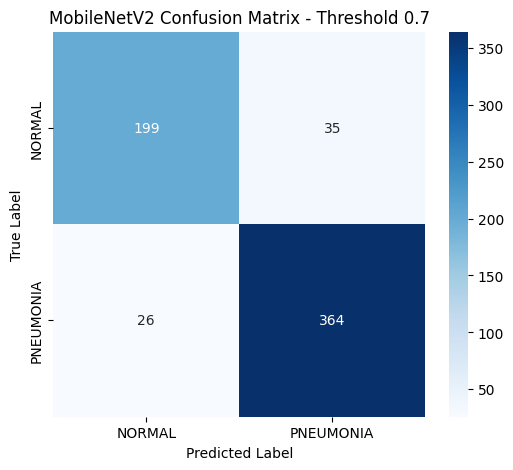

Accuracy: 0.9022435897435898
              precision    recall  f1-score   support

      NORMAL       0.88      0.85      0.87       234
   PNEUMONIA       0.91      0.93      0.92       390

    accuracy                           0.90       624
   macro avg       0.90      0.89      0.89       624
weighted avg       0.90      0.90      0.90       624



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

test_generator.reset()

y_pred_prob_mobilenet = mobilenet_model.predict(test_generator)

threshold = 0.70
y_pred_mobilenet = (y_pred_prob_mobilenet > threshold).astype("int32").flatten()

y_true = test_generator.classes

cm_mobilenet = confusion_matrix(y_true, y_pred_mobilenet)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_mobilenet,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"]
)
plt.title(f"MobileNetV2 Confusion Matrix - Threshold {threshold}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("Accuracy:", accuracy_score(y_true, y_pred_mobilenet))

print(classification_report(
    y_true,
    y_pred_mobilenet,
    target_names=["NORMAL", "PNEUMONIA"]
))

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# VGG16 base model
vgg_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# İlk aşamada hazır katmanları donduruyoruz
for layer in vgg_base.layers:
    layer.trainable = False

# Kendi sınıflandırma katmanlarımızı ekliyoruz
x = vgg_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(1, activation='sigmoid')(x)

vgg_model = Model(inputs=vgg_base.input, outputs=output)

vgg_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
early_stop_vgg = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

reduce_lr_vgg = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=0.00001
)

history_vgg = vgg_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop_vgg, reduce_lr_vgg]
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 140s 956ms/step - accuracy: 0.7036 - loss: 0.5885 - val_accuracy: 0.7430 - val_loss: 0.5026 - learning_rate: 1.0000e-04
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 107s 820ms/step - accuracy: 0.7561 - loss: 0.4873 - val_accuracy: 0.7488 - val_loss: 0.4390 - learning_rate: 1.0000e-04
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 110s 836ms/step - accuracy: 0.7882 - loss: 0.4280 - val_accuracy: 0.8025 - val_loss: 0.3897 - learning_rate: 1.0000e-04
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 110s 844ms/step - accuracy: 0.8174 - loss: 0.3800 - val_accuracy: 0.8706 - val_loss: 0.3519 - learning_rate: 1.0000e-04
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 115s 876ms/step - accuracy: 0.8476 - loss: 0.3472 - val_accuracy: 0.8792 - val_loss: 0.3261 - learning_rate: 1.0000e-04
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 113s 862ms/step - accuracy: 0.8704 - loss: 0.3160 - val_accuracy: 0.8840 - val_loss: 0.3025 - learning_rate: 1.0000e-04
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
test_loss_vgg, test_acc_vgg = vgg_model.evaluate(test_generator)

print("VGG16 Test Accuracy:", test_acc_vgg)
print("VGG16 Test Loss:", test_loss_vgg)

20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 736ms/step - accuracy: 0.8686 - loss: 0.3215
VGG16 Test Accuracy: 0.8685897588729858
VGG16 Test Loss: 0.3215402066707611


20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 332ms/step


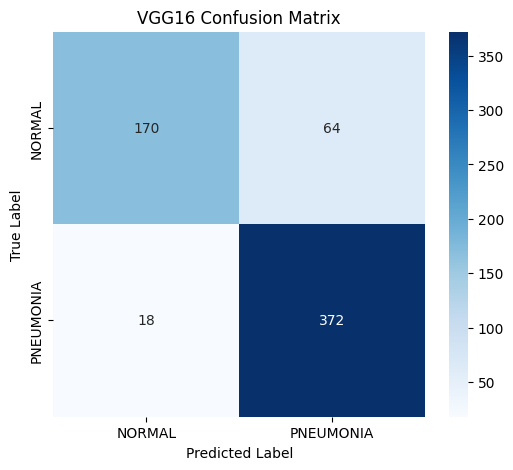

              precision    recall  f1-score   support

      NORMAL       0.90      0.73      0.81       234
   PNEUMONIA       0.85      0.95      0.90       390

    accuracy                           0.87       624
   macro avg       0.88      0.84      0.85       624
weighted avg       0.87      0.87      0.87       624



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Test generator'ı sıfırla
test_generator.reset()

# Tahmin al
vgg_preds = vgg_model.predict(test_generator)

# Olasılıkları sınıfa çevir
vgg_pred_classes = (vgg_preds > 0.5).astype("int32").reshape(-1)

# Gerçek etiketler
true_classes = test_generator.classes

# Sınıf isimleri
class_labels = list(test_generator.class_indices.keys())

# Confusion matrix
cm_vgg = confusion_matrix(true_classes, vgg_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_vgg, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title("VGG16 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Classification report
print(classification_report(true_classes, vgg_pred_classes, target_names=class_labels))

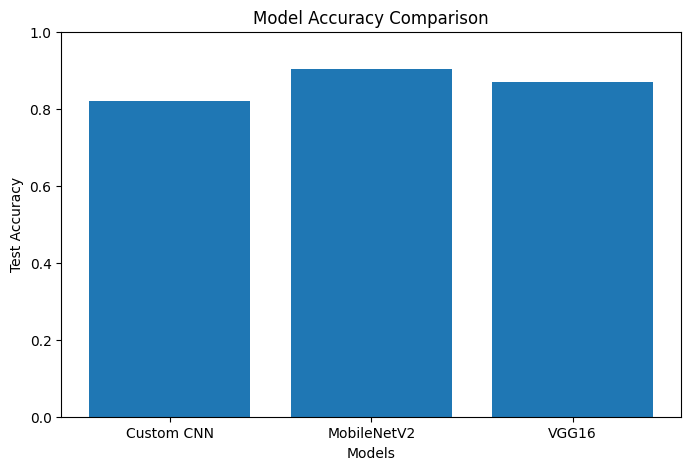

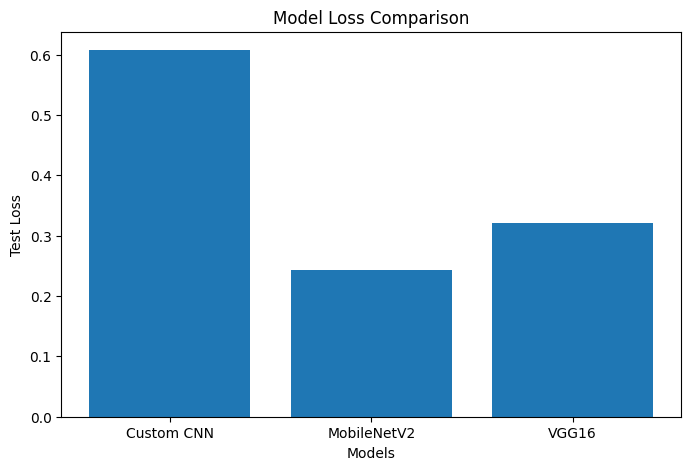

In [ ]:
models = ["Custom CNN", "MobileNetV2", "VGG16"]

accuracies = [
    0.8189102411270142,
    0.9022435897435898,
    0.8685897588729858
]

losses = [
    0.6074334979057312,
    0.24282154440879822,
    0.3215402066707611
]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(models, losses)
plt.title("Model Loss Comparison")
plt.xlabel("Models")
plt.ylabel("Test Loss")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


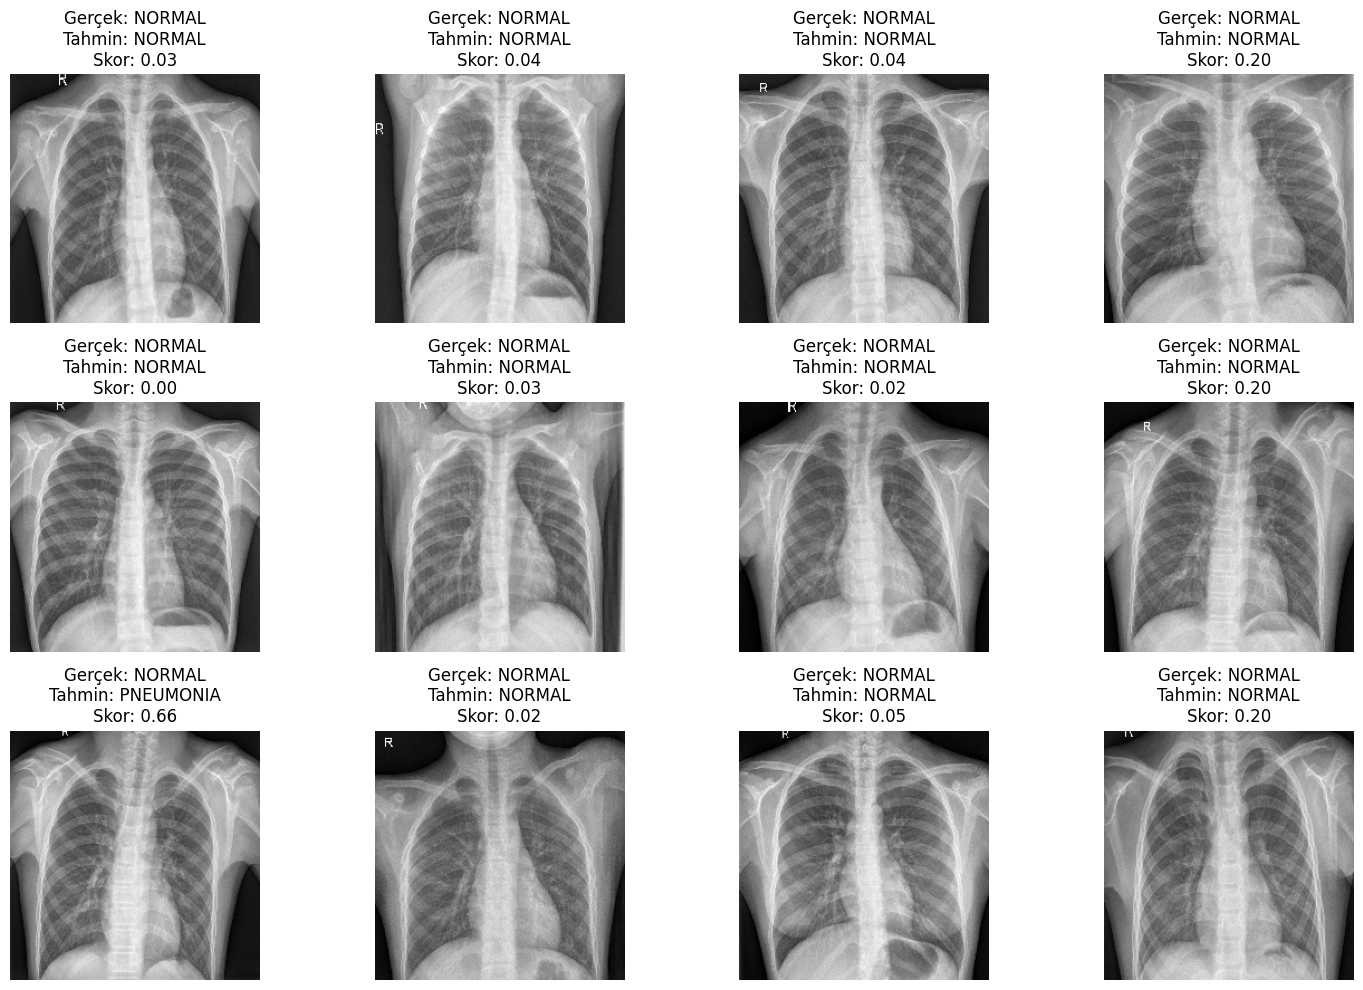

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Test generator sırasını sıfırla
test_generator.reset()

# Bir batch test görseli al
images, labels = next(test_generator)

# MobileNetV2 ile tahmin yap
predictions = mobilenet_model.predict(images)

# Sınıf isimlerini al
class_names = list(test_generator.class_indices.keys())
print("Class indices:", test_generator.class_indices)

# İlk 12 görseli göster
plt.figure(figsize=(15, 10))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i])

    true_label = int(labels[i])

    # Eğer model sigmoid kullanıyorsa
    pred_prob = predictions[i][0]
    pred_label = 1 if pred_prob > 0.5 else 0

    plt.title(
        f"Gerçek: {class_names[true_label]}\n"
        f"Tahmin: {class_names[pred_label]}\n"
        f"Skor: {pred_prob:.2f}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

test_generator.reset()

# Tüm test seti için tahmin olasılıklarını al
y_prob = mobilenet_model.predict(test_generator)
y_true = test_generator.classes

thresholds = [0.50, 0.60, 0.65, 0.70, 0.75]

for threshold in thresholds:
    y_pred = (y_prob > threshold).astype(int).reshape(-1)

    print("=" * 50)
    print(f"Threshold: {threshold}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"]))

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 217ms/step
Threshold: 0.5
Accuracy: 0.8910256410256411
Confusion Matrix:
[[178  56]
 [ 12 378]]
              precision    recall  f1-score   support

      NORMAL       0.94      0.76      0.84       234
   PNEUMONIA       0.87      0.97      0.92       390

    accuracy                           0.89       624
   macro avg       0.90      0.86      0.88       624
weighted avg       0.90      0.89      0.89       624

Threshold: 0.6
Accuracy: 0.8894230769230769
Confusion Matrix:
[[185  49]
 [ 20 370]]
              precision    recall  f1-score   support

      NORMAL       0.90      0.79      0.84       234
   PNEUMONIA       0.88      0.95      0.91       390

    accuracy                           0.89       624
   macro avg       0.89      0.87      0.88       624
weighted avg       0.89      0.89      0.89       624

Threshold: 0.65
Accuracy: 0.8958333333333334
Confusion Matrix:
[[191  43]
 [ 22 368]]
              precision    recall  f1-score   sup

In [ ]:
FINAL_THRESHOLD = 0.70
FINAL_MODEL_NAME = "MobileNetV2"

print("Final seçilen model:", FINAL_MODEL_NAME)
print("Final threshold:", FINAL_THRESHOLD)
print("Final Accuracy: 0.9022")
print("Final karar: En başarılı model MobileNetV2 seçilmiştir.")

Final seçilen model: MobileNetV2
Final threshold: 0.7
Final Accuracy: 0.9022
Final karar: En başarılı model MobileNetV2 seçilmiştir.


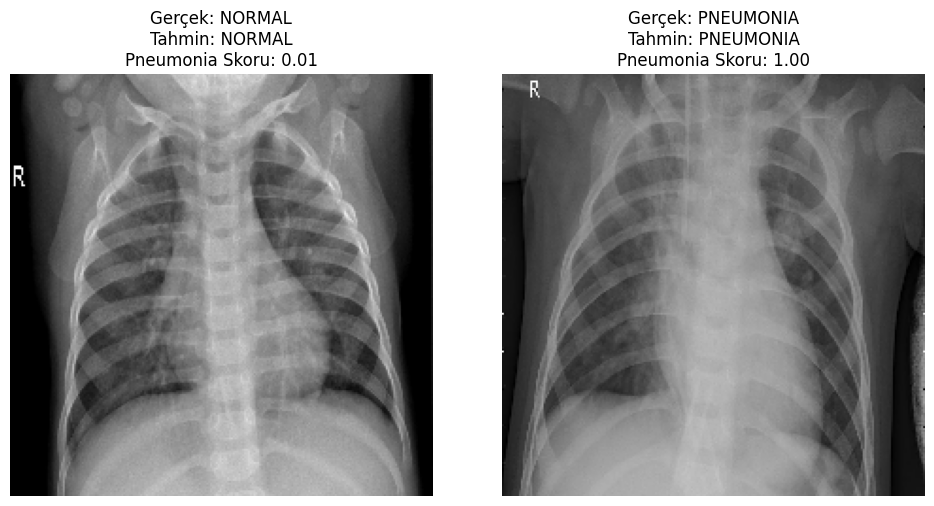

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Test klasör yolları
normal_path = "/content/dataset/chest_xray/test/NORMAL"
pneumonia_path = "/content/dataset/chest_xray/test/PNEUMONIA"

# Rastgele bir NORMAL ve bir PNEUMONIA görsel seç
sample_images = [
    (os.path.join(normal_path, random.choice(os.listdir(normal_path))), "NORMAL"),
    (os.path.join(pneumonia_path, random.choice(os.listdir(pneumonia_path))), "PNEUMONIA")
]

threshold = 0.70

plt.figure(figsize=(10, 5))

for i, (img_path, true_label) in enumerate(sample_images):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred_prob = mobilenet_model.predict(img_array, verbose=0)[0][0]

    if pred_prob > threshold:
        prediction = "PNEUMONIA"
    else:
        prediction = "NORMAL"

    plt.subplot(1, 2, i + 1)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(
        f"Gerçek: {true_label}\nTahmin: {prediction}\nPneumonia Skoru: {pred_prob:.2f}"
    )

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
mobilenet_model.save('/content/drive/MyDrive/pneumonia_mobilenetv2_model.h5')

In [ ]:
mobilenet_model.save('/content/drive/MyDrive/pneumonia_mobilenetv2_final.keras')

In [ ]:
import os

print(os.path.exists('/content/drive/MyDrive/pneumonia_mobilenetv2_model.h5'))
print(os.path.exists('/content/drive/MyDrive/pneumonia_mobilenetv2_final.keras'))

True
True


In [ ]:
from tensorflow.keras.models import load_model

loaded_model = load_model('/content/drive/MyDrive/pneumonia_mobilenetv2_final.keras')

loss, accuracy = loaded_model.evaluate(test_generator)

print("Yüklenen model accuracy:", accuracy)
print("Yüklenen model loss:", loss)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 462ms/step - accuracy: 0.8910 - loss: 0.2428
Yüklenen model accuracy: 0.8910256624221802
Yüklenen model loss: 0.24282154440879822
